# 04 — Model Evaluation

Loads the trained LSTM autoencoder and saved threshold, then produces:
- ROC curve + AUC
- Precision-Recall curve + Average Precision
- Reconstruction error vs. Remaining Useful Life
- Alert lead-time analysis (cycles before failure)
- Final metrics summary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix
)

plt.style.use('seaborn-v0_8-darkgrid')
os.makedirs('../results', exist_ok=True)

## 1. Load artifacts

In [2]:
# Data
X          = np.load('../data/processed/X_windows.npy')
y          = np.load('../data/processed/y_labels.npy')
engine_ids = np.load('../data/processed/engine_ids.npy')
rul        = np.load('../data/processed/rul_targets.npy')

# Model
autoencoder = load_model('../models/lstm_autoencoder.keras')

# Threshold
with open('../results/anomaly_threshold.txt') as f:
    threshold = float(f.read().strip())

print(f"X: {X.shape}  |  y: {y.shape}  |  threshold: {threshold:.4f}")

X: (17731, 30, 11)  |  y: (17731,)  |  threshold: 0.0937


In [3]:
# Compute reconstruction error for every window
X_pred = autoencoder.predict(X, verbose=0)
mae    = np.mean(np.abs(X_pred - X), axis=(1, 2))

print(f"MAE — normal mean: {mae[y==0].mean():.4f}  |  anomaly mean: {mae[y==1].mean():.4f}")

MAE — normal mean: 0.0850  |  anomaly mean: 0.0953


## 2. ROC Curve

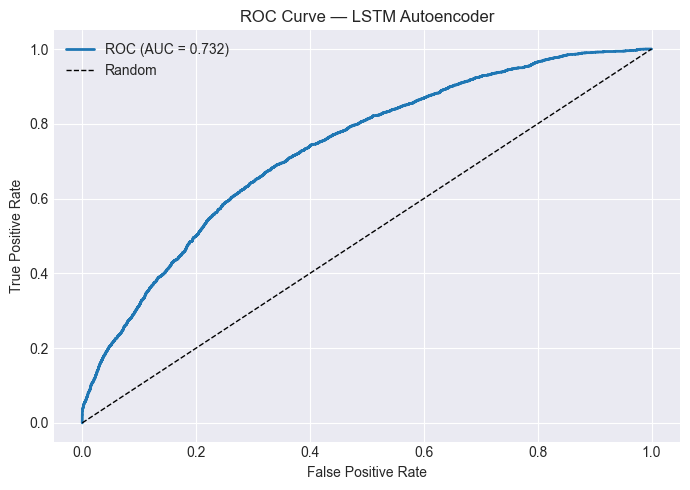

AUC: 0.7317


In [4]:
fpr, tpr, _ = roc_curve(y, mae)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — LSTM Autoencoder')
plt.legend()
plt.tight_layout()
plt.savefig('../results/roc_curve.png', dpi=150)
plt.show()
print(f"AUC: {roc_auc:.4f}")

## 3. Precision-Recall Curve

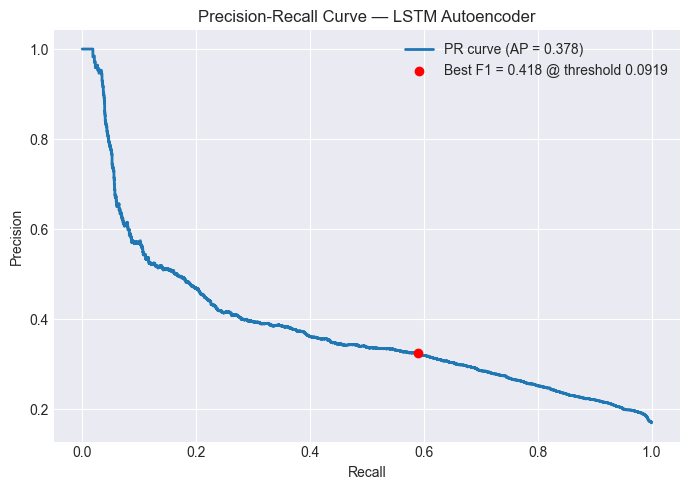

Average Precision: 0.3783
Best F1: 0.4179  at threshold 0.0919


In [5]:
precision, recall, pr_thresholds = precision_recall_curve(y, mae)
ap = average_precision_score(y, mae)

# F1 at each threshold point
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)
best_idx  = f1_scores.argmax()

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, lw=2, label=f'PR curve (AP = {ap:.3f})')
plt.scatter(recall[best_idx], precision[best_idx],
            color='red', zorder=5,
            label=f'Best F1 = {f1_scores[best_idx]:.3f} @ threshold {pr_thresholds[best_idx]:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — LSTM Autoencoder')
plt.legend()
plt.tight_layout()
plt.savefig('../results/pr_curve.png', dpi=150)
plt.show()
print(f"Average Precision: {ap:.4f}")
print(f"Best F1: {f1_scores[best_idx]:.4f}  at threshold {pr_thresholds[best_idx]:.4f}")

## 4. Reconstruction Error vs. RUL

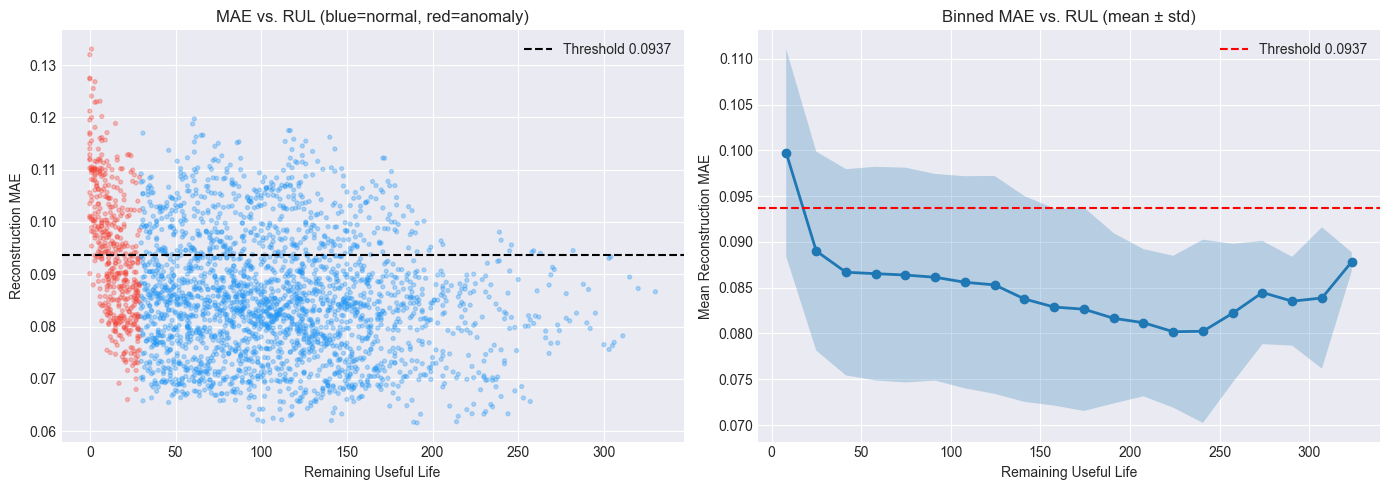

In [6]:
# Bin RUL into 20 equal-width buckets and show mean ± std of MAE per bucket
df = pd.DataFrame({'mae': mae, 'rul': rul, 'anomaly': y})
df['rul_bin'] = pd.cut(df['rul'], bins=20)
grouped = df.groupby('rul_bin', observed=True)['mae'].agg(['mean', 'std']).reset_index()
bin_centers = grouped['rul_bin'].apply(lambda x: x.mid).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter (sample 3000 points for speed)
sample_idx = np.random.choice(len(df), size=min(3000, len(df)), replace=False)
colors = ['#2196F3' if a == 0 else '#F44336' for a in df['anomaly'].iloc[sample_idx]]
axes[0].scatter(df['rul'].iloc[sample_idx], df['mae'].iloc[sample_idx],
                c=colors, alpha=0.3, s=8)
axes[0].axhline(threshold, color='black', linestyle='--', lw=1.5, label=f'Threshold {threshold:.4f}')
axes[0].set_xlabel('Remaining Useful Life')
axes[0].set_ylabel('Reconstruction MAE')
axes[0].set_title('MAE vs. RUL (blue=normal, red=anomaly)')
axes[0].legend()

# Binned mean ± std
axes[1].plot(bin_centers, grouped['mean'], marker='o', lw=2)
axes[1].fill_between(bin_centers,
                     grouped['mean'] - grouped['std'],
                     grouped['mean'] + grouped['std'],
                     alpha=0.25)
axes[1].axhline(threshold, color='red', linestyle='--', lw=1.5, label=f'Threshold {threshold:.4f}')
axes[1].set_xlabel('Remaining Useful Life')
axes[1].set_ylabel('Mean Reconstruction MAE')
axes[1].set_title('Binned MAE vs. RUL (mean ± std)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/mae_vs_rul.png', dpi=150)
plt.show()

## 5. Alert Lead-Time Analysis

For each engine, find the **first window** where MAE exceeds the threshold and record how many RUL cycles remain. A longer lead time means the model raises the alarm earlier — giving more time to act before failure.

In [7]:
lead_times = []
missed = 0

for eng in np.unique(engine_ids):
    mask    = engine_ids == eng
    eng_mae = mae[mask]
    eng_rul = rul[mask]
    alert_idx = np.where(eng_mae > threshold)[0]
    if len(alert_idx) > 0:
        first_alert_rul = eng_rul[alert_idx[0]]
        lead_times.append(first_alert_rul)
    else:
        missed += 1

lead_times = np.array(lead_times)
print(f"Engines with at least one alert: {len(lead_times)} / {len(np.unique(engine_ids))}")
print(f"Engines with no alert (missed):  {missed}")
print(f"Median lead time: {np.median(lead_times):.0f} cycles")
print(f"Mean lead time:   {lead_times.mean():.1f} cycles")
print(f"Lead time ≥ 30 cycles: {(lead_times >= 30).mean()*100:.1f}%")

Engines with at least one alert: 94 / 100
Engines with no alert (missed):  6
Median lead time: 30 cycles
Mean lead time:   74.0 cycles
Lead time ≥ 30 cycles: 50.0%


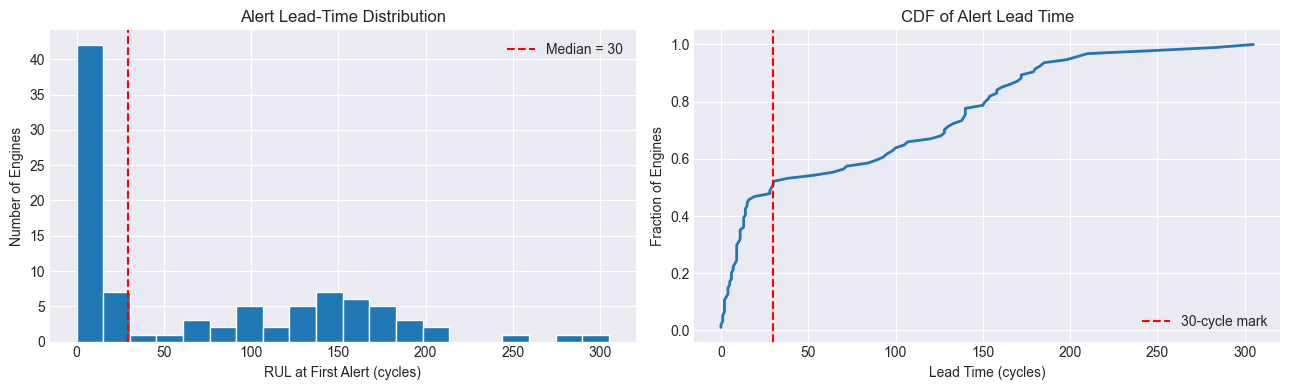

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(lead_times, bins=20, edgecolor='white')
axes[0].axvline(np.median(lead_times), color='red', linestyle='--',
                label=f'Median = {np.median(lead_times):.0f}')
axes[0].set_xlabel('RUL at First Alert (cycles)')
axes[0].set_ylabel('Number of Engines')
axes[0].set_title('Alert Lead-Time Distribution')
axes[0].legend()

# CDF
sorted_lt = np.sort(lead_times)
cdf = np.arange(1, len(sorted_lt)+1) / len(sorted_lt)
axes[1].plot(sorted_lt, cdf, lw=2)
axes[1].axvline(30, color='red', linestyle='--', label='30-cycle mark')
axes[1].set_xlabel('Lead Time (cycles)')
axes[1].set_ylabel('Fraction of Engines')
axes[1].set_title('CDF of Alert Lead Time')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/alert_lead_time.png', dpi=150)
plt.show()

## 6. Final Metrics Summary

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_pred = (mae > threshold).astype(int)

summary = {
    'ROC-AUC':             round(roc_auc, 4),
    'Average Precision':   round(ap, 4),
    'Threshold':           round(threshold, 4),
    'Precision (anomaly)': round(precision_score(y, y_pred), 4),
    'Recall (anomaly)':    round(recall_score(y, y_pred), 4),
    'F1 (anomaly)':        round(f1_score(y, y_pred), 4),
    'Engines alerted':     len(lead_times),
    'Engines missed':      int(missed),
    'Median lead time':    f'{np.median(lead_times):.0f} cycles',
    'Lead time ≥ 30 cyc':  f'{(lead_times >= 30).mean()*100:.1f}%',
}

summary_df = pd.DataFrame(summary.items(), columns=['Metric', 'Value'])
print(summary_df.to_string(index=False))

summary_df.to_csv('../results/metrics_summary.csv', index=False)
print('\nSaved to ../results/metrics_summary.csv')

             Metric     Value
            ROC-AUC    0.7317
  Average Precision    0.3783
          Threshold    0.0937
Precision (anomaly)    0.3344
   Recall (anomaly)     0.523
       F1 (anomaly)     0.408
    Engines alerted        94
     Engines missed         6
   Median lead time 30 cycles
 Lead time ≥ 30 cyc     50.0%

Saved to ../results/metrics_summary.csv


## Summary

| Metric | Value |
|---|---|
| ROC-AUC | *(run to populate)* |
| Average Precision | *(run to populate)* |
| Anomaly F1 | *(run to populate)* |
| Median lead time | *(run to populate)* |

**Artifacts saved:**
- `../results/roc_curve.png`
- `../results/pr_curve.png`
- `../results/mae_vs_rul.png`
- `../results/alert_lead_time.png`
- `../results/metrics_summary.csv`

**Next:** `05_deployment.ipynb` — FastAPI inference endpoint + Streamlit demo dashboard.